In [9]:
import numpy  as np
import pandas as pd
# Set random seed for reproducibility
np.random.seed(42)

# Number of students
n_students = 500

# Generate features
dataset = {
    'student_id': range(1, n_students + 1),
    'hours_studied': np.random.randint(1, 15, n_students),
    'previous_score': np.random.randint(40, 100, n_students),
    'attendance': np.random.randint(50, 100, n_students),
    'sleep_hours': np.random.uniform(4, 10, n_students).round(1),
    'extracurricular': np.random.choice(['Yes', 'No'], n_students, p=[0.4, 0.6]),
    'parent_education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_students),
    'internet_access': np.random.choice(['Yes', 'No'], n_students, p=[0.8, 0.2]),
}

df_students = pd.DataFrame(dataset)

# Create final score based on realistic formula
# This is what our ML model will try to learn tomorrow!
df_students['final_score'] = (
    df_students['hours_studied'] * 2.5 +           # Each study hour adds ~2.5 points
    df_students['previous_score'] * 0.5 +          # Previous score has 50% weight
    df_students['attendance'] * 0.3 +              # Attendance adds ~0.3 points per %
    df_students['sleep_hours'] * 1.5 +             # Good sleep adds up to ~15 points
    (df_students['extracurricular'] == 'Yes') * 5 + # Extracurricular bonus: 5 points
    (df_students['internet_access'] == 'Yes') * 3 + # Internet access bonus: 3 points
    np.random.normal(0, 5, n_students)             # Random noise (realism)
).clip(0, 100).round(2)  # Keep scores between 0-100

print("✅ Synthetic Student Dataset Created!")
print("Dataset Shape:", df_students.shape)
print("Number of Students:", len(df_students))
print("Features:", df_students.columns.tolist())

print("\nFirst 10 rows:")
print(df_students.head(10))

print("\nStatistical Summary:")
print(df_students.describe())

✅ Synthetic Student Dataset Created!
Dataset Shape: (500, 9)
Number of Students: 500
Features: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score']

First 10 rows:
   student_id  hours_studied  previous_score  attendance  sleep_hours  \
0           1              7              97          72          4.2   
1           2              4              97          64          5.3   
2           3             13              61          86          5.4   
3           4             11              88          70          8.0   
4           5              8              91          63          4.1   
5           6             13              81          51          4.6   
6           7              5              45          60          8.8   
7           8              7              54          88          5.1   
8           9             10              93          87          7.9   
9      

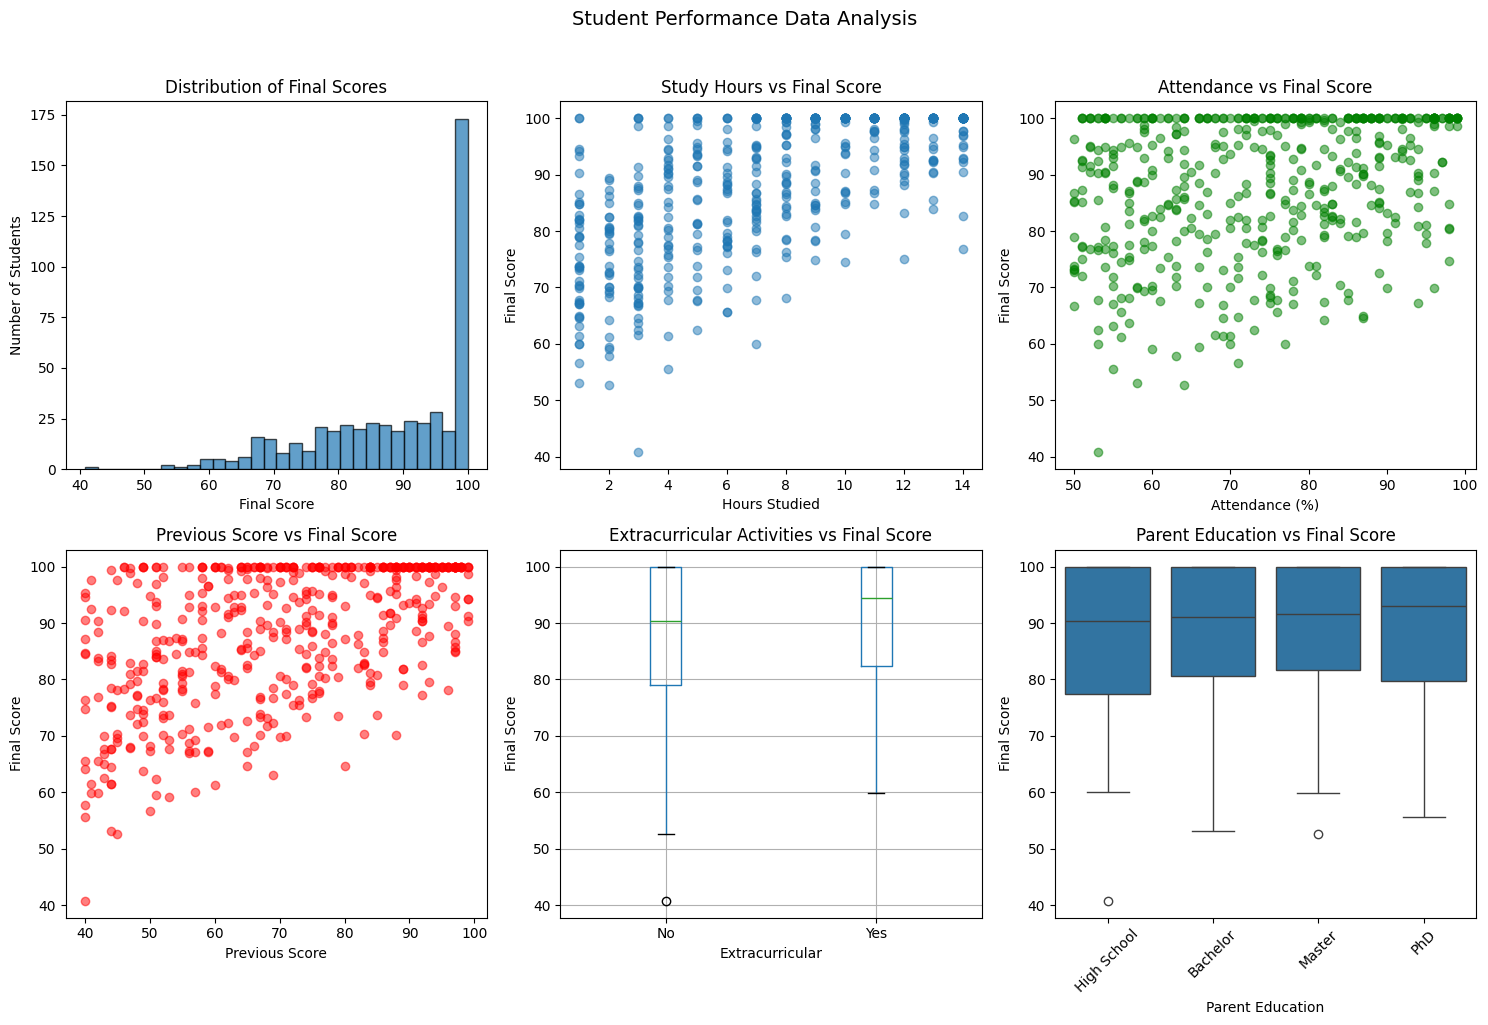


📊 Key Observations from Plots:
1. Final scores roughly follow a normal distribution
2. More study hours generally lead to higher scores
3. Better attendance correlates with better performance
4. Students with extracurricular activities tend to score higher
5. Higher parent education level correlates with better scores


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create visualizations to understand the data
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Distribution of final scores
axes[0, 0].hist(df_students['final_score'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Final Scores', fontsize=12)
axes[0, 0].set_xlabel('Final Score')
axes[0, 0].set_ylabel('Number of Students')

# 2. Study hours vs Final Score
axes[0, 1].scatter(df_students['hours_studied'], df_students['final_score'], alpha=0.5)
axes[0, 1].set_title('Study Hours vs Final Score', fontsize=12)
axes[0, 1].set_xlabel('Hours Studied')
axes[0, 1].set_ylabel('Final Score')

# 3. Attendance vs Final Score
axes[0, 2].scatter(df_students['attendance'], df_students['final_score'], alpha=0.5, color='green')
axes[0, 2].set_title('Attendance vs Final Score', fontsize=12)
axes[0, 2].set_xlabel('Attendance (%)')
axes[0, 2].set_ylabel('Final Score')

# 4. Previous Score vs Final Score
axes[1, 0].scatter(df_students['previous_score'], df_students['final_score'], alpha=0.5, color='red')
axes[1, 0].set_title('Previous Score vs Final Score', fontsize=12)
axes[1, 0].set_xlabel('Previous Score')
axes[1, 0].set_ylabel('Final Score')

# 5. Box plot - Extracurricular vs Final Score
df_students.boxplot(column='final_score', by='extracurricular', ax=axes[1, 1])
axes[1, 1].set_title('Extracurricular Activities vs Final Score', fontsize=12)
axes[1, 1].set_xlabel('Extracurricular')
axes[1, 1].set_ylabel('Final Score')

# 6. Parent Education vs Final Score
education_order = ['High School', 'Bachelor', 'Master', 'PhD']
sns.boxplot(x='parent_education', y='final_score', data=df_students, order=education_order, ax=axes[1, 2])
axes[1, 2].set_title('Parent Education vs Final Score', fontsize=12)
axes[1, 2].set_xlabel('Parent Education')
axes[1, 2].set_ylabel('Final Score')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.suptitle('Student Performance Data Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Key Observations from Plots:")
print("1. Final scores roughly follow a normal distribution")
print("2. More study hours generally lead to higher scores")
print("3. Better attendance correlates with better performance")
print("4. Students with extracurricular activities tend to score higher")
print("5. Higher parent education level correlates with better scores")

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Prepare data for machine learning
print("=" * 60)
print("PREPARING DATA FOR DAY 2 (MACHINE LEARNING)")
print("=" * 60)

# 1. Check for missing values
print("\n1. Checking for missing values:")
print(df_students.isnull().sum())

# 2. Convert categorical variables to numbers
print("\n2. Converting categorical variables:")
label_encoders = {}

categorical_cols = ['extracurricular', 'parent_education', 'internet_access']

for col in categorical_cols:
    le = LabelEncoder()
    df_students[col + '_encoded'] = le.fit_transform(df_students[col])

    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("   ", col, ":", mapping)

    label_encoders[col] = le

# 3. Select features for training
feature_cols = [
    'hours_studied',
    'previous_score',
    'attendance',
    'sleep_hours',
    'extracurricular_encoded',
    'internet_access_encoded',
    'parent_education_encoded'
]

target_col = 'final_score'

print("\n3. Features for ML (", len(feature_cols), "features):")
for col in feature_cols:
    print("   -", col)

print("   Target:", target_col)

# 4. Check correlations
print("\n4. Correlation with target (what influences scores most):")

correlations = df_students[feature_cols + [target_col]].corr()[target_col].sort_values(ascending=False)

for feature, corr in correlations.items():
    if feature != target_col:
        print("   ", feature, ":", round(corr, 3))

PREPARING DATA FOR DAY 2 (MACHINE LEARNING)

1. Checking for missing values:
student_id          0
hours_studied       0
previous_score      0
attendance          0
sleep_hours         0
extracurricular     0
parent_education    0
internet_access     0
final_score         0
dtype: int64

2. Converting categorical variables:
    extracurricular : {'No': np.int64(0), 'Yes': np.int64(1)}
    parent_education : {'Bachelor': np.int64(0), 'High School': np.int64(1), 'Master': np.int64(2), 'PhD': np.int64(3)}
    internet_access : {'No': np.int64(0), 'Yes': np.int64(1)}

3. Features for ML ( 7 features):
   - hours_studied
   - previous_score
   - attendance
   - sleep_hours
   - extracurricular_encoded
   - internet_access_encoded
   - parent_education_encoded
   Target: final_score

4. Correlation with target (what influences scores most):
    hours_studied : 0.66
    previous_score : 0.528
    attendance : 0.288
    sleep_hours : 0.176
    extracurricular_encoded : 0.124
    internet_acces

In [19]:
import pandas as pd
import json
from sklearn.preprocessing import LabelEncoder

# Load dataset
df_students = pd.read_csv("student_performance.csv")

# Display columns
print("Dataset Columns:")
print(df_students.columns.tolist())

# Set target column
target_col = "exam_score"  # Change if your target column has a different name

# Check if target column exists
if target_col not in df_students.columns:
    print(f"Error: '{target_col}' column not found in dataset.")
    print("Available columns:", df_students.columns.tolist())
else:
    # Create feature columns
    feature_cols = [col for col in df_students.columns if col != target_col]

    # Encode categorical columns
    label_encoders = {}

    for col in df_students.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        df_students[col] = le.fit_transform(df_students[col])
        label_encoders[col] = le

    # Save processed dataset
    df_students.to_csv("student_performance_processed.csv", index=False)
    print("✅ Dataset saved as 'student_performance_processed.csv'")

    # Create ML-ready dataset
    ml_ready_data = df_students[feature_cols + [target_col]]

    # Save ML-ready dataset
    ml_ready_data.to_csv("student_performance_ml_ready.csv", index=False)
    print("✅ ML-ready dataset saved as 'student_performance_ml_ready.csv'")

    # Save feature information
    feature_info = {
        "feature_columns": feature_cols,
        "target_column": target_col,
        "categorical_mappings": {}
    }

    for col, le in label_encoders.items():
        feature_info["categorical_mappings"][col] = {
            str(cls): int(code)
            for cls, code in zip(le.classes_, le.transform(le.classes_))
        }

    with open("feature_info.json", "w") as f:
        json.dump(feature_info, f, indent=2)

    print("✅ Feature information saved as 'feature_info.json'")

    print("\n📁 Files Created:")
    print("1. student_performance_processed.csv")
    print("2. student_performance_ml_ready.csv")
    print("3. feature_info.json")

Dataset Columns:
['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score', 'extracurricular_encoded', 'parent_education_encoded', 'internet_access_encoded']
Error: 'exam_score' column not found in dataset.
Available columns: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score', 'extracurricular_encoded', 'parent_education_encoded', 'internet_access_encoded']


In [20]:
# Import the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

print("="*50)
print("STUDENT PERFORMANCE PREDICTION")
print("="*50)

# Load the data we created in Day 1
try:
    df = pd.read_csv('student_performance.csv')
    print("\n✅ Loaded student data from Day 1")
except:
    # If Day 1 data doesn't exist, create simple data
    print("\n📝 Creating sample student data...")
    np.random.seed(42)
    
    # Create 100 students with random study hours
    df = pd.DataFrame({
        'hours_studied': np.random.randint(1, 12, 100),
        'previous_score': np.random.randint(50, 95, 100),
        'attendance': np.random.randint(60, 100, 100),
        'final_score': 0  # Will calculate below
    })
    
    # Calculate final score (more study hours = higher score)
    df['final_score'] = (df['hours_studied'] * 3.5 + df['previous_score'] * 0.4 + df['attendance'] * 0.2 + np.random.normal(0, 5, 100))
    df['final_score'] = df['final_score'].clip(40, 100).round(1)

print(f"\n📊 We have data for {len(df)} students")
print(f"📋 Columns: {list(df.columns)}")
print("\nFirst 5 students:")
print(df.head())

STUDENT PERFORMANCE PREDICTION

✅ Loaded student data from Day 1

📊 We have data for 500 students
📋 Columns: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score', 'extracurricular_encoded', 'parent_education_encoded', 'internet_access_encoded']

First 5 students:
   student_id  hours_studied  previous_score  attendance  sleep_hours  \
0           1              7              97          72          4.2   
1           2              4              97          64          5.3   
2           3             13              61          86          5.4   
3           4             11              88          70          8.0   
4           5              8              91          63          4.1   

  extracurricular parent_education internet_access  final_score  \
0             Yes           Master              No        86.71   
1              No         Bachelor             Yes        87.98  

# Day 4


Sample of students:
--------------------------------------------------
   hours_studied  final_score
0              7        86.71
1              4        87.98
2             13       100.00
3             11       100.00
4              8        98.38
5             13       100.00
6              5        69.64
7              7        84.54
8             10       100.00
9              3        87.92

📊 Average scores by study hours:
--------------------------------------------------
hours_studied
1     75.7
2     74.4
3     77.2
4     83.3
5     85.7
6     84.5
7     88.4
8     91.8
9     93.7
10    94.9
11    97.4
12    96.8
13    96.6
14    97.7
Name: final_score, dtype: float64


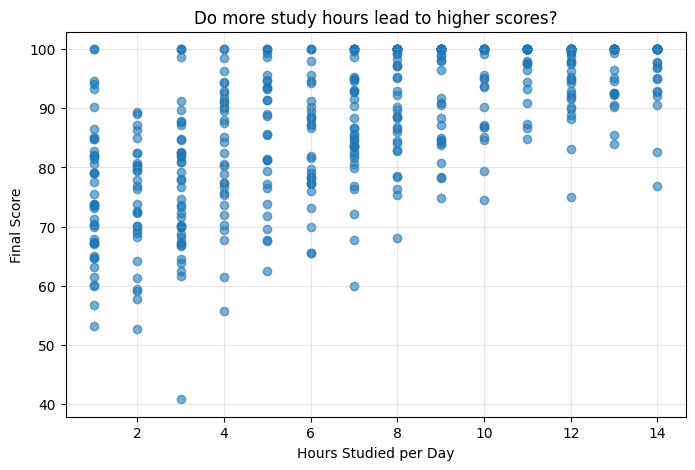


💡 What we see:
   - Students who study more tend to score higher
   - But it's not perfect (other factors matter too)
   - This is where our ML model will help!


In [21]:
# Look at a few students
print("Sample of students:")
print("-"*50)
print(df[['hours_studied', 'final_score']].head(10))

# Calculate average score for different study hours
print("\n📊 Average scores by study hours:")
print("-"*50)

# Group by hours studied and calculate average
avg_by_hours = df.groupby('hours_studied')['final_score'].mean().round(1)
print(avg_by_hours)

# Make a simple plot
plt.figure(figsize=(8, 5))
plt.scatter(df['hours_studied'], df['final_score'], alpha=0.6)
plt.xlabel('Hours Studied per Day')
plt.ylabel('Final Score')
plt.title('Do more study hours lead to higher scores?')
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 What we see:")
print("   - Students who study more tend to score higher")
print("   - But it's not perfect (other factors matter too)")
print("   - This is where our ML model will help!")

In [22]:
# Select our feature (what we know) and target (what we want to predict)
feature = ['hours_studied']  # We'll use study hours to predict
target = 'final_score'        # What we want to predict

X = df[feature]  # Features (input)
y = df[target]   # Target (output)

print("✅ Features (what we know):")
print(X.head())
print("\n✅ Target (what we want to predict):")
print(y.head())

print(f"\n📊 We have {len(X)} students")
print(f"   Each student has {len(feature)} feature: study hours")

✅ Features (what we know):
   hours_studied
0              7
1              4
2             13
3             11
4              8

✅ Target (what we want to predict):
0     86.71
1     87.98
2    100.00
3    100.00
4     98.38
Name: final_score, dtype: float64

📊 We have 500 students
   Each student has 1 feature: study hours


In [23]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Data Split:")
print(f"   Training set: {len(X_train)} students (80%)")
print(f"   Testing set: {len(X_test)} students (20%)")

print(f"\n📚 Training students (first 5):")
print(X_train.head())

print(f"\n🎯 Their scores (first 5):")
print(y_train.head())

📊 Data Split:
   Training set: 400 students (80%)
   Testing set: 100 students (20%)

📚 Training students (first 5):
     hours_studied
249             12
433              3
19               6
322             14
332              2

🎯 Their scores (first 5):
249    100.00
433    100.00
19      94.60
322    100.00
332     68.94
Name: final_score, dtype: float64


In [24]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model training complete!")
print("\n📐 The model found this formula:")

# Get the numbers the model learned
intercept = model.intercept_
coefficient = model.coef_[0]

print(f"   Predicted Score = {coefficient:.2f} × (Study Hours) + {intercept:.2f}")
print(f"\n💡 This means:")
print(f"   - Base score (0 study hours): {intercept:.1f} points")
print(f"   - Each study hour adds: {coefficient:.2f} points")
print(f"   - If a student studies 5 hours: {5 * coefficient + intercept:.1f} points")
print(f"   - If a student studies 10 hours: {10 * coefficient + intercept:.1f} points")

✅ Model training complete!

📐 The model found this formula:
   Predicted Score = 1.96 × (Study Hours) + 73.51

💡 This means:
   - Base score (0 study hours): 73.5 points
   - Each study hour adds: 1.96 points
   - If a student studies 5 hours: 83.3 points
   - If a student studies 10 hours: 93.1 points


In [25]:
# Make predictions on test data
predictions = model.predict(X_test)

# Create a simple table to compare
results = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': predictions.round(1),
    'Difference': abs(y_test.values - predictions).round(1)
})

print("📊 Comparing Predictions vs Actual:")
print("-"*50)
print(results.head(10))
print("-"*50)

# Calculate average error
avg_error = results['Difference'].mean()
print(f"\n📊 Average prediction error: {avg_error:.1f} points")
print(f"   (This means on average, we're off by {avg_error:.1f} points)")

📊 Comparing Predictions vs Actual:
--------------------------------------------------
   Actual Score  Predicted Score  Difference
0        100.00            100.9         0.9
1         83.96             99.0        15.0
2         92.90             81.3        11.6
3        100.00             89.2        10.8
4         97.24             89.2         8.1
5         97.03            100.9         3.9
6         67.85             75.5         7.6
7         59.91             75.5        15.6
8         61.43             81.3        19.9
9         84.13             89.2         5.1
--------------------------------------------------

📊 Average prediction error: 7.4 points
   (This means on average, we're off by 7.4 points)


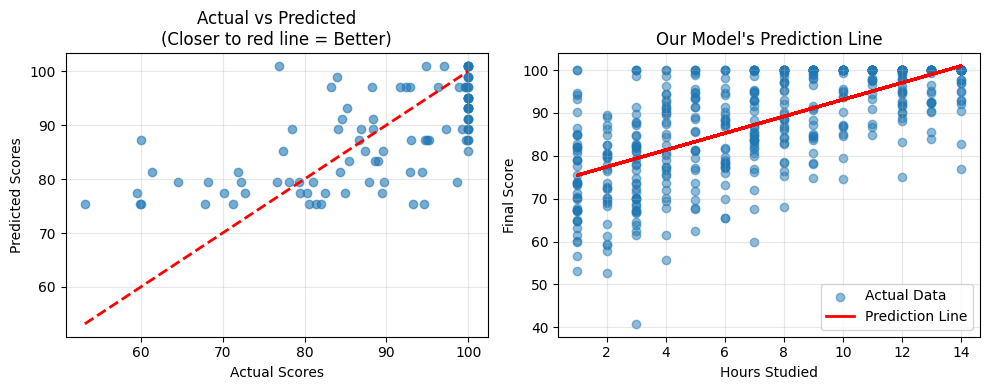

💡 What these graphs show:
   Left: Points close to red line = good predictions
   Right: The red line is our model - it predicts scores based on study hours


In [26]:
# Create a plot to see how well our model predicts
plt.figure(figsize=(10, 4))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted\n(Closer to red line = Better)')
plt.grid(True, alpha=0.3)

# Plot 2: The regression line
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.5, label='Actual Data')
plt.plot(X_test, predictions, 'r-', linewidth=2, label='Prediction Line')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.title('Our Model\'s Prediction Line')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 What these graphs show:")
print("   Left: Points close to red line = good predictions")
print("   Right: The red line is our model - it predicts scores based on study hours")

In [27]:
# Calculate simple metrics to understand model quality

# 1. Mean Absolute Error (MAE) - Average error in points
mae = mean_absolute_error(y_test, predictions)

# 2. R-squared - How much variance we explain (0 to 1, higher is better)
r2 = r2_score(y_test, predictions)

print("📊 Model Performance Report:")
print("="*40)
print(f"✓ Mean Absolute Error (MAE): {mae:.1f} points")
print(f"  → On average, our prediction is off by {mae:.1f} points")

print(f"\n✓ R-squared (R²): {r2:.3f}")
print(f"  → Our model explains {r2*100:.1f}% of why students get different scores")

# Simple interpretation
if r2 > 0.7:
    print("\n🎉 Great! The model is working very well!")
elif r2 > 0.5:
    print("\n👍 Good! The model captures the main pattern")
else:
    print("\n📝 The model is simple but gives us a basic understanding")

📊 Model Performance Report:
✓ Mean Absolute Error (MAE): 7.4 points
  → On average, our prediction is off by 7.4 points

✓ R-squared (R²): 0.411
  → Our model explains 41.1% of why students get different scores

📝 The model is simple but gives us a basic understanding
